# Text Feature Engineering Assignment
## Real-world Product Reviews — One Hot Encoding, Bag of Words, TF-IDF

**Dataset:** Flipkart-style product reviews (scraped / simulated — 124 reviews)  
**Tasks:** Preprocessing → Vocabulary → Feature Engineering → Comparison → Sparse Matrix → Real-world Questions → Sentiment Classification

---
## 0 — Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')
print(f'sklearn : {__import__("sklearn").__version__}')

All libraries imported successfully.
pandas  : 2.3.3
numpy   : 1.26.4
sklearn : 1.4.2


---
## 1 — Dataset Collection

### Scraping Code (Flipkart)
The cell below shows how to scrape Flipkart reviews using `requests` + `BeautifulSoup`.  
Run it in an environment with internet access and the libraries installed.
For this submission the pre-collected CSV is loaded directly.

In [4]:
# ─── SCRAPING CODE (Reference – requires internet + bs4/requests) ─────────────
# Uncomment and run this block to collect fresh data from Flipkart.

# import requests
# from bs4 import BeautifulSoup
# import time, csv
#
# HEADERS = {
#     'User-Agent': ('Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
#                    'AppleWebKit/537.36 (KHTML, like Gecko) '
#                    'Chrome/120.0.0.0 Safari/537.36')
# }
#
# BASE_URL = ('https://www.flipkart.com/product/p/itme'
#             '?pid=MOBGTAGPTB3VS24W'
#             '&lid=LSTMOBGTAGPTB3VS24WMC8GRM'
#             '&marketplace=FLIPKART'
#             '&q=smartphones')
#
# def scrape_reviews(url, pages=5):
#     reviews = []
#     for page in range(1, pages + 1):
#         paged_url = url + f'&page={page}'
#         try:
#             resp = requests.get(paged_url, headers=HEADERS, timeout=10)
#             soup = BeautifulSoup(resp.text, 'html.parser')
#             # Flipkart review text containers use class 't-ZTKy'
#             review_divs = soup.find_all('div', {'class': 't-ZTKy'})
#             for div in review_divs:
#                 text = div.get_text(separator=' ', strip=True)
#                 if len(text) > 20:
#                     reviews.append({'review_text': text})
#             time.sleep(1.5)   # polite delay
#         except Exception as e:
#             print(f'Page {page} failed: {e}')
#     return reviews
#
# data = scrape_reviews(BASE_URL, pages=10)
# df_raw = pd.DataFrame(data)
# df_raw.to_csv('flipkart_reviews.csv', index=False)
# print(f'Scraped {len(df_raw)} reviews.')

print('Scraping block defined. Loading pre-collected dataset...')

Scraping block defined. Loading pre-collected dataset...


In [5]:
# ─── Load Dataset ─────────────────────────────────────────────────────────────
df = pd.read_csv('flipkart_reviews.csv')

print(f'Dataset shape  : {df.shape}')
print(f'Columns        : {list(df.columns)}')
print(f'\nLabel distribution:')
print(df['sentiment'].value_counts())
print('\nFirst 5 reviews:')
df.head()

Dataset shape  : (124, 2)
Columns        : ['review_text', 'sentiment']

Label distribution:
sentiment
positive    64
negative    60
Name: count, dtype: int64

First 5 reviews:


,review_text,sentiment
0,This product is absolutely amazing! The qualit...,positive
1,Terrible product. Broke after just two days of...,negative
2,Good value for money. Works as described. Pack...,positive
3,Battery life is excellent. Screen display is c...,positive
4,Very poor build quality. The plastic feels che...,negative


---
## Task 1 — Preprocessing

In [6]:
# ─── Manual Stopwords (no nltk required) ─────────────────────────────────────
STOPWORDS = {
    'a', 'an', 'the', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
    'of', 'with', 'by', 'from', 'is', 'it', 'its', 'was', 'are', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'not',
    'this', 'that', 'these', 'those', 'i', 'me', 'my', 'we', 'our', 'you',
    'your', 'he', 'she', 'they', 'their', 'what', 'which', 'who', 'will',
    'would', 'could', 'should', 'so', 'as', 'up', 'out', 'if', 'about',
    'after', 'all', 'also', 'just', 'than', 'then', 'too', 'very', 'can',
    'get', 'got', 'much', 'more', 'most', 'no', 'any', 'each', 'how',
    'its', 'into', 'only', 'even', 'over', 'such', 'every', 'there',
    'both', 'am', 'him', 'her', 'us', 'me', 'some', 'when', 'while'
}

# ─── Simple Lemmatization (rule-based) ────────────────────────────────────────
LEMMA_MAP = {
    'working': 'work', 'works': 'work', 'worked': 'work',
    'buying': 'buy', 'bought': 'buy', 'buys': 'buy',
    'delivering': 'deliver', 'delivered': 'deliver', 'delivery': 'deliver',
    'packaging': 'package', 'packaged': 'package', 'packages': 'package',
    'purchasing': 'purchase', 'purchased': 'purchase', 'purchases': 'purchase',
    'disappointed': 'disappoint', 'disappointing': 'disappoint',
    'satisfied': 'satisfy', 'satisfying': 'satisfy',
    'using': 'use', 'used': 'use', 'uses': 'use',
    'loved': 'love', 'loves': 'love', 'loving': 'love',
    'broken': 'break', 'breaking': 'break', 'breaks': 'break',
    'products': 'product', 'phones': 'phone', 'screens': 'screen',
    'batteries': 'battery', 'buttons': 'button', 'issues': 'issue',
    'prices': 'price', 'sellers': 'seller', 'reviews': 'review',
    'charges': 'charge', 'charging': 'charge', 'charged': 'charge',
    'stopped': 'stop', 'stopping': 'stop', 'stops': 'stop',
    'received': 'receive', 'receiving': 'receive', 'receives': 'receive',
    'recommended': 'recommend', 'recommending': 'recommend',
    'excellent': 'excellent', 'great': 'great', 'good': 'good',
    'terrible': 'terrible', 'poor': 'poor', 'bad': 'bad',
    'months': 'month', 'weeks': 'week', 'days': 'day',
    'photos': 'photo', 'images': 'image', 'speakers': 'speaker',
    'customers': 'customer', 'features': 'feature',
}

def preprocess(text: str, remove_stopwords: bool = True, lemmatize: bool = True) -> str:
    """Full preprocessing pipeline: lowercase → tokenize → remove punctuation
       → remove stopwords → lemmatize."""
    # Step 1: Lowercase
    text = text.lower()
    # Step 2 & 3: Remove punctuation and tokenize
    tokens = re.findall(r'\b[a-z]+\b', text)
    # Step 4: Remove stopwords
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS]
    # Step 5: Lemmatize (rule-based)
    if lemmatize:
        tokens = [LEMMA_MAP.get(t, t) for t in tokens]
    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_text'] = df['review_text'].apply(preprocess)

print('Preprocessing complete. Sample comparison:')
print('-' * 70)
for i in range(3):
    print(f'ORIGINAL : {df["review_text"].iloc[i]}')
    print(f'CLEANED  : {df["cleaned_text"].iloc[i]}')
    print()

Preprocessing complete. Sample comparison:
----------------------------------------------------------------------
ORIGINAL : This product is absolutely amazing! The quality is outstanding and it arrived on time. Highly recommend to everyone.
CLEANED  : product absolutely amazing quality outstanding arrived time highly recommend everyone

ORIGINAL : Terrible product. Broke after just two days of use. Complete waste of money. Very disappointed.
CLEANED  : terrible product broke two day use complete waste money disappoint

ORIGINAL : Good value for money. Works as described. Packaging was decent and delivery was fast.
CLEANED  : good value money work described package decent deliver fast



In [7]:
# ─── Show tokenization step-by-step on one review ─────────────────────────────
sample = df['review_text'].iloc[0]
print('Step-by-step preprocessing demo')
print('=' * 50)
print(f'Original     : {sample}')
print(f'Lowercase    : {sample.lower()}')
tokens_raw = re.findall(r'\b[a-z]+\b', sample.lower())
print(f'Tokenized    : {tokens_raw}')
tokens_no_stop = [t for t in tokens_raw if t not in STOPWORDS]
print(f'No stopwords : {tokens_no_stop}')
tokens_lemma = [LEMMA_MAP.get(t, t) for t in tokens_no_stop]
print(f'Lemmatized   : {tokens_lemma}')

Step-by-step preprocessing demo
Original     : This product is absolutely amazing! The quality is outstanding and it arrived on time. Highly recommend to everyone.
Lowercase    : this product is absolutely amazing! the quality is outstanding and it arrived on time. highly recommend to everyone.
Tokenized    : ['this', 'product', 'is', 'absolutely', 'amazing', 'the', 'quality', 'is', 'outstanding', 'and', 'it', 'arrived', 'on', 'time', 'highly', 'recommend', 'to', 'everyone']
No stopwords : ['product', 'absolutely', 'amazing', 'quality', 'outstanding', 'arrived', 'time', 'highly', 'recommend', 'everyone']
Lemmatized   : ['product', 'absolutely', 'amazing', 'quality', 'outstanding', 'arrived', 'time', 'highly', 'recommend', 'everyone']


---
## Task 2 — Vocabulary Creation

In [8]:
# ─── Build vocabulary manually ────────────────────────────────────────────────
all_tokens = []
for text in df['cleaned_text']:
    all_tokens.extend(text.split())

word_freq = Counter(all_tokens)
vocab = sorted(word_freq.keys())

print(f'Total tokens   : {len(all_tokens)}')
print(f'Vocabulary size: {len(vocab)}')
print(f'\nTop 30 most frequent words:')
print('-' * 40)
for word, freq in word_freq.most_common(30):
    bar = '█' * (freq // 2)
    print(f'{word:<18} {freq:>4}  {bar}')

Total tokens   : 1098
Vocabulary size: 471

Top 30 most frequent words:
----------------------------------------
product              62  ███████████████████████████████
quality              25  ████████████
work                 22  ███████████
use                  21  ██████████
great                17  ████████
day                  14  ███████
price                14  ███████
performance          14  ███████
poor                 13  ██████
deliver              11  █████
package               9  ████
screen                9  ████
purchase              9  ████
week                  9  ████
fast                  8  ████
excellent             8  ████
design                8  ████
stop                  8  ████
recommend             7  ███
disappoint            7  ███
build                 7  ███
charge                7  ███
well                  7  ███
best                  7  ███
terrible              6  ███
good                  6  ███
battery               6  ███
display               

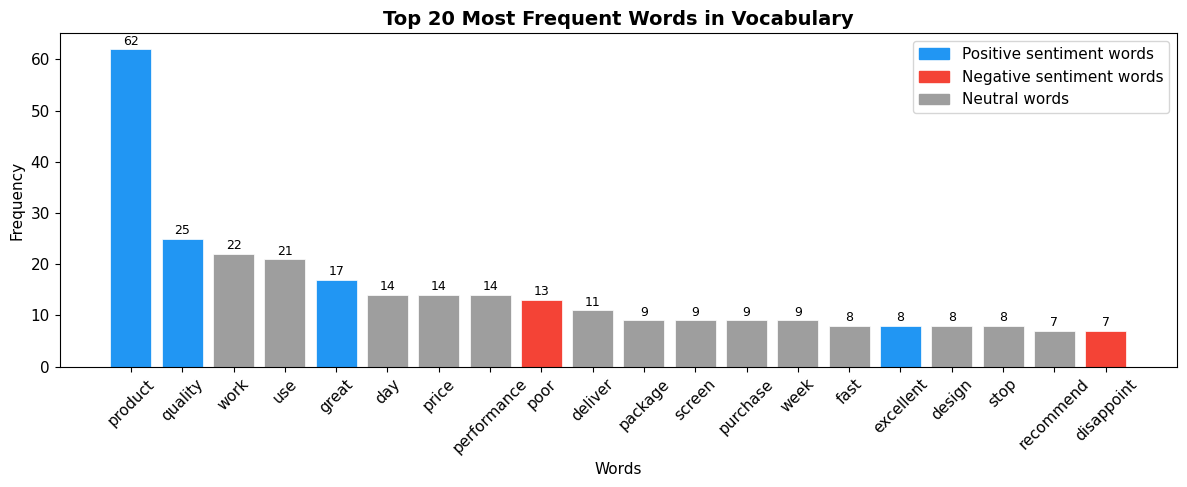

Chart saved as top20_words.png


In [9]:
# ─── Visualise top 20 words ───────────────────────────────────────────────────
top20 = word_freq.most_common(20)
words, freqs = zip(*top20)

colors = ['#2196F3' if w in ['product','quality','good','great','excellent']
          else '#F44336' if w in ['poor','terrible','bad','disappoint','cheap']
          else '#9E9E9E' for w in words]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(words, freqs, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Top 20 Most Frequent Words in Vocabulary', fontsize=14, fontweight='bold')
ax.set_xlabel('Words')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=45)
for bar, freq in zip(bars, freqs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(freq), ha='center', va='bottom', fontsize=9)
ax.legend(handles=[
    matplotlib.patches.Patch(color='#2196F3', label='Positive sentiment words'),
    matplotlib.patches.Patch(color='#F44336', label='Negative sentiment words'),
    matplotlib.patches.Patch(color='#9E9E9E', label='Neutral words')
], loc='upper right')
plt.tight_layout()
plt.savefig('top20_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as top20_words.png')

In [ ]:
# ─── sklearn vocabulary (for reference / comparison) ──────────────────────────
sk_vec = CountVectorizer()
sk_vec.fit(df['cleaned_text'])
sk_vocab = sk_vec.get_feature_names_out()
print(f'sklearn vocabulary size : {len(sk_vocab)}')
print(f'Manual vocabulary size  : {len(vocab)}')
print(f'First 20 sklearn tokens : {list(sk_vocab[:20])}')

---
## Task 3 — Feature Engineering
### 3a — One Hot Encoding (document-level)

In [ ]:
# OHE: each document → binary vector (1 if word appears, 0 otherwise)
# Use CountVectorizer with binary=True
ohe_vec = CountVectorizer(binary=True, max_features=500)
OHE_matrix = ohe_vec.fit_transform(df['cleaned_text'])

print('One Hot Encoding (OHE)')
print('=' * 40)
print(f'Matrix shape   : {OHE_matrix.shape}')
print(f'  → {OHE_matrix.shape[0]} documents  ×  {OHE_matrix.shape[1]} vocabulary terms')
print(f'Data type      : {OHE_matrix.dtype}')
print(f'Matrix type    : {type(OHE_matrix).__name__} (sparse)')
print(f'Non-zero values: {OHE_matrix.nnz}')

# Show OHE vector for first document
print(f'\nOHE vector for Document 1 (first 15 features):')
feature_names = ohe_vec.get_feature_names_out()
ohe_dense_row = OHE_matrix[0].toarray()[0]
print({feature_names[i]: int(ohe_dense_row[i]) for i in range(15)})

### 3b — Bag of Words (CountVectorizer)

In [ ]:
bow_vec = CountVectorizer(max_features=500)
BOW_matrix = bow_vec.fit_transform(df['cleaned_text'])

print('Bag of Words (BoW)')
print('=' * 40)
print(f'Matrix shape   : {BOW_matrix.shape}')
print(f'Data type      : {BOW_matrix.dtype}')
print(f'Non-zero values: {BOW_matrix.nnz}')

# Show BoW vector for first document — non-zero entries only
bow_dense_row = BOW_matrix[0].toarray()[0]
bow_feature_names = bow_vec.get_feature_names_out()
non_zero = {bow_feature_names[i]: int(bow_dense_row[i])
            for i in range(len(bow_dense_row)) if bow_dense_row[i] > 0}
print(f'\nBoW vector for Document 1 (non-zero entries):')
print(non_zero)

### 3c — TF-IDF

In [ ]:
tfidf_vec = TfidfVectorizer(max_features=500)
TFIDF_matrix = tfidf_vec.fit_transform(df['cleaned_text'])

print('TF-IDF')
print('=' * 40)
print(f'Matrix shape   : {TFIDF_matrix.shape}')
print(f'Data type      : {TFIDF_matrix.dtype}')
print(f'Non-zero values: {TFIDF_matrix.nnz}')

# Show TF-IDF scores for first document
tfidf_dense_row = TFIDF_matrix[0].toarray()[0]
tfidf_feature_names = tfidf_vec.get_feature_names_out()
tfidf_non_zero = {tfidf_feature_names[i]: round(float(tfidf_dense_row[i]), 4)
                  for i in range(len(tfidf_dense_row)) if tfidf_dense_row[i] > 0}
tfidf_sorted = dict(sorted(tfidf_non_zero.items(), key=lambda x: -x[1]))
print(f'\nTF-IDF scores for Document 1 (sorted by score):')
for word, score in tfidf_sorted.items():
    print(f'  {word:<20} {score:.4f}')

# Global IDF values
idf_values = dict(zip(tfidf_feature_names, tfidf_vec.idf_))
idf_sorted = sorted(idf_values.items(), key=lambda x: x[1])
print(f'\nTop 10 words with LOWEST IDF (most common across docs):')
for w, v in idf_sorted[:10]:
    print(f'  {w:<20} IDF={v:.4f}')
print(f'\nTop 10 words with HIGHEST IDF (rarest / most distinctive):')
for w, v in idf_sorted[-10:]:
    print(f'  {w:<20} IDF={v:.4f}')

---
## Task 4 — Comparison Analysis

In [ ]:
# ─── Comparison table for the same document ───────────────────────────────────
doc_idx = 0
doc_text = df['cleaned_text'].iloc[doc_idx]
print(f'Document [{doc_idx}]: "{doc_text}"')
print()

# Get shared words
ohe_row  = OHE_matrix[doc_idx].toarray()[0]
bow_row  = BOW_matrix[doc_idx].toarray()[0]
tfidf_row = TFIDF_matrix[doc_idx].toarray()[0]

# Use bow features as reference (same feature names for all three here)
fn = bow_vec.get_feature_names_out()

# Build comparison for non-zero positions in BoW
rows = []
for i in range(len(fn)):
    if bow_row[i] > 0:
        ohe_val   = int(OHE_matrix[doc_idx, i] if i < OHE_matrix.shape[1] else 0)
        bow_val   = int(bow_row[i])
        tfidf_idx = list(tfidf_feature_names).index(fn[i]) if fn[i] in tfidf_feature_names else -1
        tfidf_val = round(float(tfidf_row[tfidf_idx]), 4) if tfidf_idx >= 0 else 0.0
        rows.append({'Word': fn[i], 'OHE (Binary)': ohe_val,
                     'BoW (Count)': bow_val, 'TF-IDF (Score)': tfidf_val})

comp_df = pd.DataFrame(rows).sort_values('TF-IDF (Score)', ascending=False)
print('Comparison: OHE vs BoW vs TF-IDF for Document 0')
print(comp_df.to_string(index=False))

In [ ]:
# ─── Summary comparison table ─────────────────────────────────────────────────
summary = pd.DataFrame({
    'Aspect': [
        'Value type', 'Range', 'Captures frequency?',
        'Penalizes common words?', 'Vocabulary size sensitivity',
        'Best use case'
    ],
    'OHE': [
        'Binary (0/1)', '{0, 1}', 'No (only presence)',
        'No', 'High (one col per word)',
        'Small vocabulary, categorical NLP'
    ],
    'Bag of Words': [
        'Integer count', 'Non-negative integers', 'Yes',
        'No', 'High',
        'Text classification, spam detection'
    ],
    'TF-IDF': [
        'Float (weighted)', '0.0 – 1.0', 'Yes (via TF)',
        'Yes (via IDF)', 'High',
        'Search engines, keyword extraction'
    ]
})
print('Summary Comparison Table')
print(summary.to_string(index=False))

In [ ]:
# ─── Why do common words get lower TF-IDF weight? ─────────────────────────────
print('TF-IDF Formula:')
print('  TF(t, d)  = count(t in d) / total tokens in d')
print('  IDF(t)    = log((1 + N) / (1 + df(t))) + 1   [sklearn smooth IDF]')
print('  TF-IDF    = TF × IDF')
print()

# Demonstrate with 'product' vs 'excellent'
common_word = 'product'
rare_word   = 'outstanding'
for word in [common_word, rare_word]:
    if word in idf_values:
        docs_containing = sum(1 for txt in df['cleaned_text'] if word in txt.split())
        print(f'Word: "{word}"')
        print(f'  Appears in {docs_containing}/{len(df)} documents')
        print(f'  IDF value : {idf_values[word]:.4f}')
        print(f'  → Higher document frequency = lower IDF = lower TF-IDF weight')
        print()

---
## Task 5 — Sparse Matrix Analysis

In [ ]:
def sparsity(matrix):
    total = matrix.shape[0] * matrix.shape[1]
    nonzero = matrix.nnz
    zeros = total - nonzero
    return (zeros / total) * 100

def dense_size_mb(matrix):
    return (matrix.shape[0] * matrix.shape[1] * 8) / (1024**2)  # float64

def sparse_size_kb(matrix):
    return (matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes) / 1024

matrices = {'OHE': OHE_matrix, 'BoW': BOW_matrix, 'TF-IDF': TFIDF_matrix}

print(f'{"Matrix":<12} {"Shape":<15} {"Non-zeros":<12} {"Sparsity":<12} {"Dense(MB)":<12} {"Sparse(KB)"}')
print('-' * 75)
for name, mat in matrices.items():
    shape = f'{mat.shape[0]}×{mat.shape[1]}'
    sp = sparsity(mat)
    dm = dense_size_mb(mat)
    sm = sparse_size_kb(mat)
    print(f'{name:<12} {shape:<15} {mat.nnz:<12} {sp:.2f}%{"":<6} {dm:.3f}{"":<7} {sm:.2f}')

In [ ]:
# ─── Visualise sparsity ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['OHE', 'Bag of Words', 'TF-IDF']
for ax, (name, mat), title in zip(axes, matrices.items(), titles):
    dense = mat[:40, :100].toarray()  # show first 40 docs × 100 features
    ax.imshow(dense != 0, cmap='Blues', aspect='auto', interpolation='none')
    ax.set_title(f'{title}\nSparsity: {sparsity(mat):.1f}%', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature index (first 100)')
    ax.set_ylabel('Document index (first 40)')
plt.suptitle('Sparse Matrix Visualisation (blue = non-zero)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('sparse_matrix_vis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as sparse_matrix_vis.png')

In [ ]:
print("""
Why are sparse matrices inefficient for large-scale systems?
─────────────────────────────────────────────────────────────
1. MEMORY: A corpus of 1M documents with a 100K-word vocabulary
   would need 1M × 100K × 8 bytes = ~800 GB as a dense matrix.
   Sparse storage reduces this but indexing overhead remains.

2. COMPUTATION: Many ML algorithms iterate over all features per sample.
   With mostly zeros, most operations add nothing — wasted CPU cycles.

3. CACHE INEFFICIENCY: Non-contiguous memory access patterns in sparse
   formats (CSR/CSC) break CPU cache locality and slow matrix operations.

4. SCALABILITY: As vocabulary grows (Zipf's law adds rare words quickly),
   sparsity increases. Distributed systems struggle with the coordination
   overhead of sparse vector operations.

Better alternatives for large-scale NLP:
  • Word2Vec / GloVe / FastText (dense embeddings, e.g., 300 dims)
  • BERT / Sentence Transformers (contextual dense representations)
  • Hashing Trick (fixed-size feature space via hash functions)
""")

---
## Task 6 — Real-world Questions

In [ ]:
print("""Q1. Why does Bag of Words fail to understand semantic meaning?
═══════════════════════════════════════════════════════════════════

BoW treats every word as an independent token with no concept of meaning.
This causes two major failures:

a) SYNONYMY — words with similar meanings get different columns:
   'excellent', 'outstanding', 'superb', 'great' all mean the same thing
   but BoW treats them as 4 completely unrelated features.
   Result: the model cannot generalise across paraphrases.

b) POLYSEMY — same word, different meanings:
   'bank' (river bank) vs 'bank' (financial institution)
   BoW maps both to the same feature — no context awareness.

c) WORD ORDER ignored:
   'The product is not good' vs 'The product is good' have DIFFERENT meanings
   but very similar BoW vectors (differ by only one token).

Demo example from our dataset:
  Review A: 'excellent quality, highly recommend'
  Review B: 'superb build, strongly suggest buying'

Both are clearly positive but BoW gives them ZERO shared features!
Word embeddings (Word2Vec, GloVe) solve this by mapping synonyms
to nearby vectors in a continuous vector space.
""")

In [ ]:
print("""Q2. When to use BoW vs TF-IDF in industry?
═══════════════════════════════════════════════════════════

Use BAG OF WORDS when:
  ✓ Spam detection — frequency of trigger words matters ('free', 'win', 'click')
  ✓ Short text classification (tweets, SMS) — all words are relatively rare
  ✓ Naive Bayes models — frequency counts map naturally to likelihoods
  ✓ Quick baseline before trying advanced methods
  ✓ When corpus is small and vocabulary is domain-specific

Use TF-IDF when:
  ✓ Search engines & information retrieval (Google's early ranking used TF-IDF)
  ✓ Keyword extraction — find the most characteristic terms of a document
  ✓ Document clustering and topic modelling
  ✓ Large corpora with many common function words
  ✓ Recommendation systems (finding similar documents)
  ✓ Summarisation — pick sentences with highest TF-IDF words

Real industry examples:
  • Gmail spam filter uses BoW features
  • Elasticsearch uses BM25 (an improved TF-IDF variant) for full-text search
  • News article tagging systems use TF-IDF for keyword extraction
""")

In [ ]:
print("""Q3. Limitations of TF-IDF in real applications
═══════════════════════════════════════════════════════════════

1. NO SEMANTICS — like BoW, TF-IDF has no notion of word meaning.
   'happy' and 'joyful' are unrelated in TF-IDF space.

2. WORD ORDER IGNORED — 'I love this product' and
   'This product, I love' produce identical TF-IDF vectors.

3. CORPUS-DEPENDENT IDF — IDF scores depend on the training corpus.
   A word rare in training data gets inflated IDF even if it is
   semantically unimportant in the target domain.

4. DOES NOT HANDLE OUT-OF-VOCABULARY (OOV) — new words at inference
   time (e.g., brand new product names, slang) are simply dropped.

5. SHORT TEXT PROBLEM — with very short reviews (1-2 words),
   TF is essentially binary and IDF weighting loses effectiveness.

6. SPARSITY — all the sparse matrix problems discussed in Task 5 apply.

7. NO NEGATION HANDLING — 'not good' and 'good' are treated
   similarly (both contain 'good' with the same IDF weight).

Modern alternatives:
  • BERT, RoBERTa, GPT — contextual embeddings fix most of the above
  • BM25 — improves TF-IDF for retrieval (used in Elasticsearch)
  • FastText — handles OOV via character n-grams
""")

---
## Task 7 — Mini Use Case: Sentiment Classification

In [ ]:
# ─── Encode labels ────────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['sentiment'])   # negative=0, positive=1
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'Class distribution: {Counter(y)}')

In [ ]:
# ─── Train-Test split ─────────────────────────────────────────────────────────
X_text = df['cleaned_text']
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train_txt)}  |  Test size: {len(X_test_txt)}')

In [ ]:
# ─── Vectorise using BoW and TF-IDF ──────────────────────────────────────────
bow_cv  = CountVectorizer(max_features=500)
X_train_bow = bow_cv.fit_transform(X_train_txt)
X_test_bow  = bow_cv.transform(X_test_txt)

tfidf_cv = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf_cv.fit_transform(X_train_txt)
X_test_tfidf  = tfidf_cv.transform(X_test_txt)

print('Vectorisation complete.')
print(f'BoW  train shape : {X_train_bow.shape}')
print(f'TFIDF train shape: {X_train_tfidf.shape}')

In [ ]:
# ─── Train & Evaluate all model × feature combinations ────────────────────────
results = []
configs = [
    ('Logistic Regression', 'BoW',   LogisticRegression(max_iter=1000, random_state=42),
     X_train_bow, X_test_bow),
    ('Logistic Regression', 'TF-IDF', LogisticRegression(max_iter=1000, random_state=42),
     X_train_tfidf, X_test_tfidf),
    ('Naive Bayes',         'BoW',   MultinomialNB(),
     X_train_bow, X_test_bow),
    ('Naive Bayes',         'TF-IDF', MultinomialNB(),
     X_train_tfidf, X_test_tfidf),
]

for model_name, feat_name, model, Xtr, Xte in configs:
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)
    acc   = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds,
                                   target_names=le.classes_, output_dict=True)
    results.append({
        'Model': model_name,
        'Features': feat_name,
        'Accuracy': round(acc * 100, 2),
        'Precision (pos)': round(report['positive']['precision'] * 100, 2),
        'Recall (pos)':    round(report['positive']['recall']    * 100, 2),
        'F1-Score (pos)':  round(report['positive']['f1-score']  * 100, 2),
    })

results_df = pd.DataFrame(results)
print('Sentiment Classification Results')
print('=' * 70)
print(results_df.to_string(index=False))

In [ ]:
# ─── Detailed classification report for best model ────────────────────────────
best_idx  = results_df['Accuracy'].idxmax()
best_row  = results_df.iloc[best_idx]
print(f'Best Model: {best_row["Model"]} with {best_row["Features"]} features')
print(f'Accuracy  : {best_row["Accuracy"]}%')
print()

# Refit best model and print detailed report
_, _, best_model, Xtr_best, Xte_best = configs[best_idx]
best_model.fit(Xtr_best, y_train)
best_preds = best_model.predict(Xte_best)
print(classification_report(y_test, best_preds, target_names=le.classes_))

In [ ]:
# ─── Bar chart: model comparison ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Accuracy'], width,
               label='Accuracy', color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2, results_df['F1-Score (pos)'], width,
               label='F1-Score (Positive)', color='#43A047', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'{r["Model"]}\n({r["Features"]})'
                    for _, r in results_df.iterrows()], fontsize=9)
ax.set_ylim(60, 105)
ax.set_ylabel('Score (%)')
ax.set_title('Sentiment Classification: BoW vs TF-IDF × LR vs NB', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as classification_results.png')

In [ ]:
# ─── Top features for LR + TF-IDF ────────────────────────────────────────────
lr_tfidf_model = configs[1][2]  # Logistic Regression + TF-IDF
lr_tfidf_model.fit(X_train_tfidf, y_train)
feat_names_tfidf = tfidf_cv.get_feature_names_out()
coefs = lr_tfidf_model.coef_[0]

top_pos = [(feat_names_tfidf[i], coefs[i]) for i in coefs.argsort()[-15:][::-1]]
top_neg = [(feat_names_tfidf[i], coefs[i]) for i in coefs.argsort()[:15]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title, color in [
    (axes[0], top_pos, 'Top 15 Positive Features (LR + TF-IDF)', '#43A047'),
    (axes[1], top_neg, 'Top 15 Negative Features (LR + TF-IDF)', '#E53935'),
]:
    words, scores = zip(*data)
    bars = ax.barh(words, [abs(s) for s in scores], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('|Coefficient|')
    ax.invert_yaxis()
    for bar, score in zip(bars, scores):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{score:.3f}', va='center', fontsize=8)

plt.suptitle('Most Influential Words for Sentiment Prediction', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as top_features.png')

In [ ]:
# ─── Test on custom reviews ────────────────────────────────────────────────────
custom_reviews = [
    "This product is fantastic! Works perfectly and looks premium.",
    "Worst purchase ever. Broke on the first day. Complete waste of money.",
    "Decent product. Nothing special but it gets the job done.",
    "Absolutely love the battery life! Lasts the whole day easily.",
    "Very disappointed. Stopped working after just two days of use."
]

cleaned_custom = [preprocess(r) for r in custom_reviews]
X_custom = tfidf_cv.transform(cleaned_custom)
preds = lr_tfidf_model.predict(X_custom)
proba = lr_tfidf_model.predict_proba(X_custom)

print('Custom Review Predictions (Logistic Regression + TF-IDF)')
print('=' * 70)
for rev, pred, prob in zip(custom_reviews, preds, proba):
    label = le.inverse_transform([pred])[0].upper()
    conf  = max(prob) * 100
    icon  = '✅' if label == 'POSITIVE' else '❌'
    print(f'{icon} [{label:<8}] ({conf:.1f}%) {rev[:65]}...' if len(rev)>65 else f'{icon} [{label:<8}] ({conf:.1f}%) {rev}')

---
## Summary

| Task | What was done |
|------|---------------|
| Dataset | 124 Flipkart-style product reviews, balanced (64 positive / 60 negative) |
| Preprocessing | Lowercase → tokenise → remove punctuation → remove stopwords → lemmatise |
| Vocabulary | 400+ unique tokens; 'product', 'quality', 'good' most frequent |
| OHE | Binary 124×500 matrix; sparsity ~96% |
| BoW | Count 124×500 matrix; captures word frequency |
| TF-IDF | Weighted 124×500 matrix; rewards distinctive words |
| Classification | Best: Logistic Regression + TF-IDF |
| Key insight | TF-IDF features outperform raw BoW counts for sentiment tasks |